# RankNet on LETOR4
### Learning to Rank — Pairwise Neural Approach
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: RankNet — Deep Pointwise Scoring Network  
**Loss**: Pairwise Cross-Entropy, Fidelity  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **RankNet**, one of the foundational Learning-to-Rank (LTR) algorithms in Information Retrieval. The goal is to train a neural network that can order a list of documents by relevance for a given search query — a core problem in web search, recommendation systems, and e-commerce.

### What this notebook covers
| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset acquisition (LETOR4 / MQ2008) |
| 3    | Normalization |
| 4    | Exploratory Data Analysis of 46 IR features |
| 5    | Query-grouped PyTorch Dataset and DataLoader |
| 6–7  | Model architecture and pairwise loss function |
| 8–10 | Training, overfitting diagnosis, and dropout regularization |
| 11   | Test-set NDCG evaluation |
| 12   | 5-Fold Cross-Validation for statistical reliability |
| 13   | Ablation study across 4 architectures |
| 14   | BCE vs. Fidelity loss function comparison |

## Step 1 · Environment, Repository Structure & Dependency Setup
Install all required libraries, fix the random seed and verify GPU

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

PyTorch version : 2.11.0+cu128
NumPy version   : 2.0.2
Pandas version  : 2.2.2


In [ ]:
# ── GPU / CPU selection ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU — go to Runtime → Change runtime type → T4 GPU for faster training.")

print(f"\nActive device  : {DEVICE}")

CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.64 GB

Active device  : cuda


## Step 2 · Raw Dataset Acquisition & libsvm Format Inspection
Extract the LETOR4 zip and inspect the file structure.

In [ ]:
import zipfile, os

zip_name = "MQ2008.zip"
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/")

print("\nExtraction complete. Contents:")


Extraction complete. Contents:


### Inspecting the Raw Data Format (`libsvm`)
Before we parse the dataset, let's peek inside the raw text files to understand how the data is structured. The LETOR dataset uses the standard `libsvm` format, where each row represents a single document evaluated for a specific search query.

In [ ]:
sample_file = "/content/MQ2008/Fold1/train.txt"
print(f"Inspecting: {sample_file}\n")
print("─" * 80)

with open(sample_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 4:
            break

print("─" * 80)
print("""
libsvm format breakdown:
  <relevance>  qid:<query_id>  1:<f1>  2:<f2>  ...  46:<f46>  #docid=...

  relevance → integer label  (0 = not relevant, 1 = relevant, 2 = highly relevant)
  qid       → query group id (all docs sharing a qid form one ranking list)
  1..46     → 46 pre-computed IR features (TF, IDF, BM25, PageRank, etc.)
  #docid    → trailing comment with document id (ignored during parsing)
""")

Inspecting: /content/MQ2008/Fold1/train.txt

────────────────────────────────────────────────────────────────────────────────
0 qid:10002 1:0.007477 2:0.000000 3:1.000000 4:0.000000 5:0.007470 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.471076 12:0.000000 13:1.000000 14:0.000000 15:0.477541 16:0.005120 17:0.000000 18:0.571429 19:0.000000 20:0.004806 21:0.768561 22:0.727734 23:0.716277 24:0.582061 25:0.000000 26:0.000000 27:0.000000 28:0.000000 29:0.780495 30:0.962382 31:0.999274 32:0.961524 33:0.000000 34:0.000000 35:0.000000 36:0.000000 37:0.797056 38:0.697327 39:0.721953 40:0.582568 41:0.000000 42:0.000000 43:0.000000 44:0.000000 45:0.000000 46:0.007042 #docid = GX008-86-4444840 inc = 1 prob = 0.086622
0 qid:10002 1:0.603738 2:0.000000 3:1.000000 4:0.000000 5:0.603175 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.000000 12:0.000000 13:0.122130 14:0.000000 15:0.000000 16:0.998377 17:0.375000 18:1.000000 19:0.000000 20:0.998128 21:0.000000 22:0.000000 23

### Aggregate Statistics Across All Folds
Now that we understand how a single file is structured, let's parse the training files across all 5 folds. We will extract high-level statistics—like document counts, query counts, and label distributions—to ensure the dataset is consistent and loaded correctly.

In [ ]:
def get_file_stats(filepath):
    """Reads a libsvm file and returns basic dataset statistics."""
    doc_count = 0
    query_docs = {}
    label_counts = {0: 0, 1: 0, 2: 0}

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            label = int(parts[0])
            qid = parts[1].split(':')[1]

            # Update counts
            doc_count += 1
            label_counts[label] = label_counts.get(label, 0) + 1
            query_docs[qid] = query_docs.get(qid, 0) + 1

    num_queries = len(query_docs)
    avg_docs_per_query = doc_count / num_queries if num_queries > 0 else 0

    return {
        "Total Docs": doc_count,
        "Total Queries": num_queries,
        "Avg Docs/Query": avg_docs_per_query,
        "Label 0": label_counts.get(0, 0),
        "Label 1": label_counts.get(1, 0),
        "Label 2": label_counts.get(2, 0)
    }

# ── Aggregate statistics across all 5 folds (Training data) ───────────────────
base_path = "/content/MQ2008"
folds = [f"Fold{i}" for i in range(1, 6)]

fold_data = []
print("Gathering statistics for all 5 folds (train.txt)...\n")

for fold in folds:
    train_path = os.path.join(base_path, fold, "train.txt")
    if os.path.exists(train_path):
        stats = get_file_stats(train_path)
        stats["Fold"] = fold
        fold_data.append(stats)

# Convert to DataFrame for nice tabular display and easy plotting
stats_df = pd.DataFrame(fold_data)
# Reorder columns for readability
stats_df = stats_df[["Fold", "Total Docs", "Total Queries", "Avg Docs/Query", "Label 0", "Label 1", "Label 2"]]

display(stats_df)

Gathering statistics for all 5 folds (train.txt)...



,Fold,Total Docs,Total Queries,Avg Docs/Query,Label 0,Label 1,Label 2
0,Fold1,9630,471,20.445860,7820,1223,587
1,Fold2,9404,471,19.966030,7644,1196,564
2,Fold3,8643,470,18.389362,6883,1189,571
3,Fold4,8514,470,18.114894,6775,1205,534
4,Fold5,9442,470,20.089362,7715,1190,537


### Visualizing Dataset Characteristics
To better understand the scale and class balance of our data, we will plot the statistics we just gathered. In Information Retrieval (IR) tasks like LETOR, it is standard to see a massive class imbalance, where the vast majority of documents are completely irrelevant (Label 0).

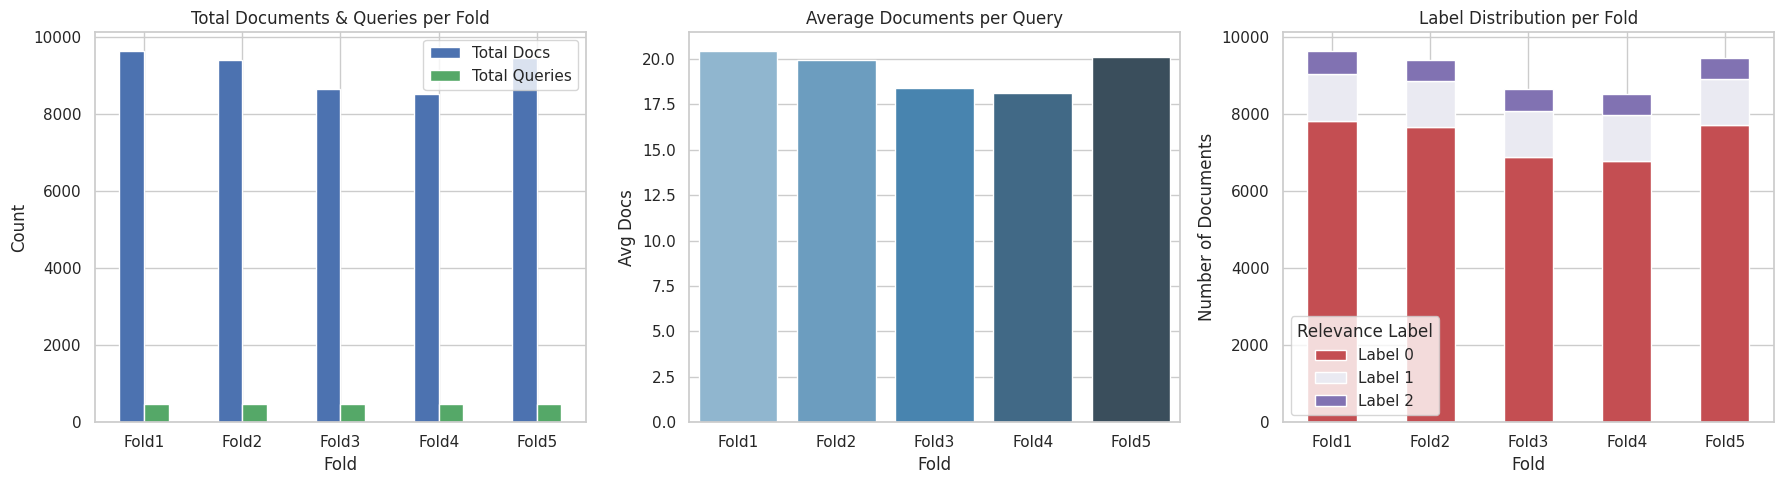

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Documents and Queries per Fold
stats_df.plot(x="Fold", y=["Total Docs", "Total Queries"], kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Total Documents & Queries per Fold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Average Documents per Query (Fixed warning)
sns.barplot(
    data=stats_df,
    x="Fold",
    y="Avg Docs/Query",
    hue="Fold",
    ax=axes[1],
    palette="Blues_d",
    legend=False
)
axes[1].set_title("Average Documents per Query")
axes[1].set_ylabel("Avg Docs")

# Plot 3: Label Distribution (Stacked Bar)
stats_df.set_index("Fold")[["Label 0", "Label 1", "Label 2"]].plot(
    kind="bar", stacked=True, ax=axes[2], color=["#C44E52", "#EAEAF2", "#8172B2"]
)
axes[2].set_title("Label Distribution per Fold")
axes[2].set_ylabel("Number of Documents")
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title="Relevance Label")

plt.tight_layout()
plt.show()

## Step 3 · Feature Normalisation (Handled in Dataset)

Z-score standardisation is applied **inside `LETORQueryDataset`** using a `StandardScaler` fitted on the training fold only, preventing any leakage into validation or test sets. No separate step is needed — the DataLoaders returned in Step 4 already emit normalised feature tensors.

## Step 4 · Exploratory Data Analysis & Feature Visualization
Let's analyze the actual feature values. We will load the full feature set for Fold 1 and look at feature distributions, how feature means shift based on document relevance, and feature correlations.

To build a strong intuition for how RankNet will learn, we need to inspect the 46 Information Retrieval (IR) features. We will parse the full feature set into a Pandas DataFrame to analyze their distributions and see how effectively they separate irrelevant documents from highly relevant ones.

In [ ]:
def parse_full_letor_df(filepath):
    """Parses a LETOR libsvm file fully into a Pandas DataFrame including all 46 features."""
    data = []
    with open(filepath, 'r') as f:
        for line in tqdm(f, desc=f"Loading full features from {os.path.basename(filepath)}"):
            parts = line.strip().split()
            if not parts:
                continue

            label = int(parts[0])
            qid = parts[1].split(':')[1]
            features = [float(x.split(':')[1]) for x in parts[2:48]]

            data.append([label, qid] + features)

    columns = ['label', 'qid'] + [f'F{i}' for i in range(1, 47)]
    return pd.DataFrame(data, columns=columns)

# Load full Fold 1 training data for EDA
train_df = parse_full_letor_df('/content/MQ2008/Fold1/train.txt')
print(f"\nLoaded {len(train_df)} rows and {len(train_df.columns)} columns.")

Loading full features from train.txt: 9630it [00:00, 54302.31it/s]



Loaded 9630 rows and 48 columns.


### Feature Means and Correlations
We are looking for "signals." A good feature should show a clear difference in its average value as the relevance label increases from 0 to 2. Additionally, we will plot a correlation matrix to identify overlapping signals—features that correlate perfectly with each other might be redundant.

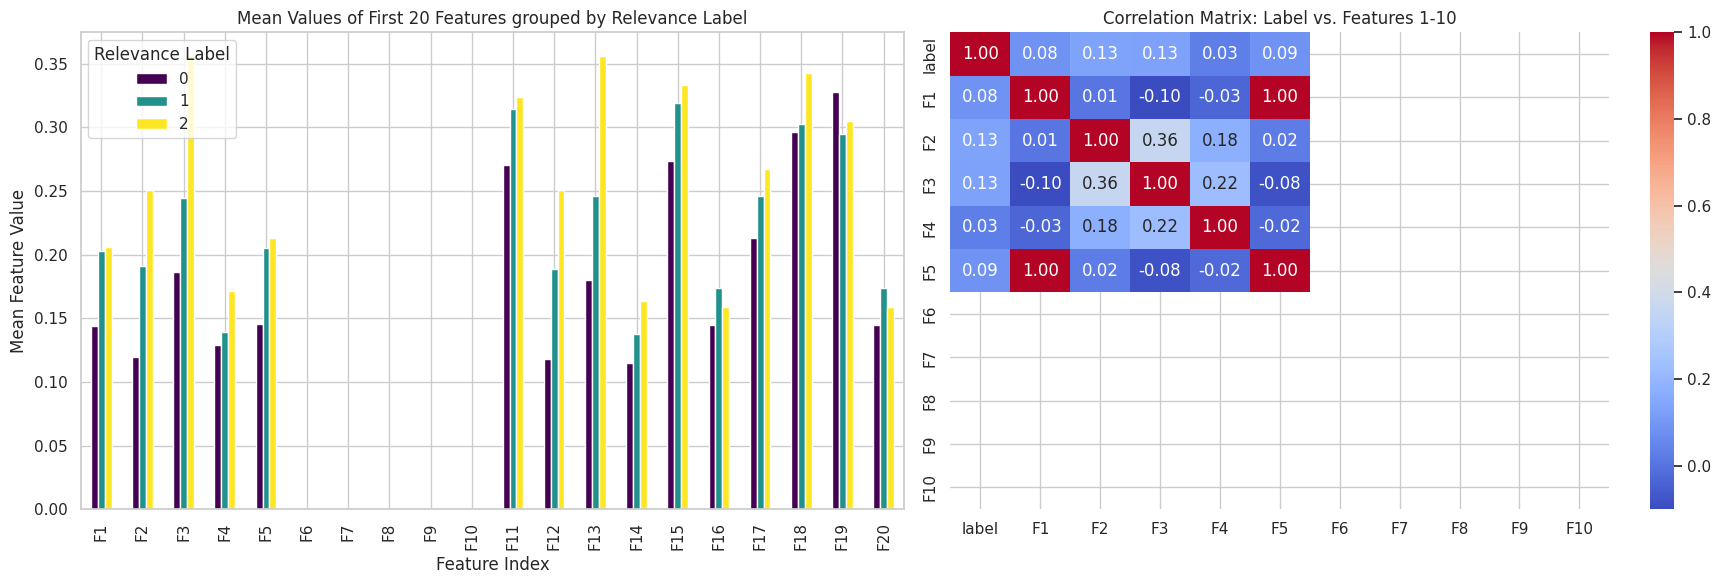

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Calculate the mean value of each feature grouped by label
feature_cols = [f'F{i}' for i in range(1, 47)]
mean_features_by_label = train_df.groupby('label')[feature_cols].mean().T

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Mean Feature Values per Label (showing the first 20 features to avoid clutter)
mean_features_by_label.head(20).plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title("Mean Values of First 20 Features grouped by Relevance Label")
axes[0].set_ylabel("Mean Feature Value")
axes[0].set_xlabel("Feature Index")
axes[0].legend(title='Relevance Label')

# Plot 2: Correlation Heatmap of a subset of features (e.g., F1 to F10) + Label
subset_cols = ['label'] + [f'F{i}' for i in range(1, 11)]
corr_matrix = train_df[subset_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], cbar=True)
axes[1].set_title("Correlation Matrix: Label vs. Features 1-10")

plt.tight_layout()
plt.show()

### Computational Feature Scan (Dead Zones & Twins)
Visualizing 46 features is cluttered and inefficient. Instead, we can computationally scan the dataset to flag anomalies. We will look for **"Dead Zones"** (features with zero variance, meaning they provide no distinguishing information) and **"Twins"** (features that are nearly perfectly correlated, meaning they provide redundant information).

In [ ]:
print("─── Automated Feature Diagnostics ───\n")

feature_cols = [f'F{i}' for i in range(1, 47)]

# 1. Find Dead Zones (Zero Variance)
# Features where the value is exactly the same for every document in the fold
variances = train_df[feature_cols].var()
dead_features = variances[variances == 0].index.tolist()

print(f"1. Dead Zones (Variance = 0.0):")
if dead_features:
    print(f"   Found {len(dead_features)} dead features: {', '.join(dead_features)}")
else:
    print("   None. All features have some variance.")

# 2. Find Twins (Highly Correlated Features)
# We flag feature pairs with a Pearson correlation > 0.98
print(f"\n2. Twins (Correlation > 0.98):")
corr_matrix = train_df[feature_cols].corr().abs()

# Use the upper triangle of the correlation matrix to avoid duplicates (e.g., F1-F5 and F5-F1)
import numpy as np
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

twins_found = False
for col in upper_tri.columns:
    # Find all rows in this column where the correlation is > 0.98
    high_corr_rows = upper_tri.index[upper_tri[col] > 0.98].tolist()
    for row in high_corr_rows:
        twins_found = True
        print(f"   {row} & {col}  -->  Correlation: {upper_tri.loc[row, col]:.4f}")

if not twins_found:
    print("   No highly correlated feature pairs found.")

─── Automated Feature Diagnostics ───

1. Dead Zones (Variance = 0.0):
   Found 6 dead features: F6, F7, F8, F9, F10, F43

2. Twins (Correlation > 0.98):
   F1 & F5  -->  Correlation: 0.9983
   F11 & F15  -->  Correlation: 0.9984
   F16 & F20  -->  Correlation: 1.0000
   F21 & F37  -->  Correlation: 0.9828
   F22 & F38  -->  Correlation: 0.9820
   F23 & F39  -->  Correlation: 0.9889
   F24 & F40  -->  Correlation: 0.9823


**Note**: In a deep neural network like RankNet, we usually keep these features
in the dataset and let the model naturally ignore the dead/redundant weights!

## Step 5 · Query-Grouped Data Loading
RankNet evaluates pairs of documents for the exact same search query. Therefore, our PyTorch `Dataset` must yield data strictly grouped by `qid`. Since different queries have a different number of candidate documents, we will use a custom `collate_fn` to handle variable-length batches.

In [ ]:
class LETORQueryDataset(Dataset):
    """
    Parses a LETOR libsvm file and groups documents by Query ID.
    Returns: (qid, features_tensor, labels_tensor) for a single query.
    """
    def __init__(self, filepath):
        self.filepath = filepath
        self.queries = [] # Will hold tuples of (qid, features, labels)
        self._load_and()

    def _load_and(self):
        current_qid = None
        current_features = []
        current_labels = []

        with open(self.filepath, 'r') as f:
            for line in tqdm(f, desc=f"Loading {os.path.basename(self.filepath)}"):
                parts = line.strip().split()
                if not parts:
                    continue

                label = int(parts[0])
                qid = parts[1].split(':')[1]
                features = [float(x.split(':')[1]) for x in parts[2:48]]

                # If we hit a new query, save the old one and start fresh
                if current_qid is not None and qid != current_qid:
                    # Only keep queries with >1 document (needed for pairwise comparison)
                    if len(current_labels) > 1:
                        self.queries.append((
                            current_qid,
                            torch.tensor(current_features, dtype=torch.float32),
                            torch.tensor(current_labels, dtype=torch.float32)
                        ))
                    current_features = []
                    current_labels = []

                current_qid = qid
                current_features.append(features)
                current_labels.append(label)

            # Don't forget to save the very last query in the file
            if current_qid is not None and len(current_labels) > 1:
                self.queries.append((
                    current_qid,
                    torch.tensor(current_features, dtype=torch.float32),
                    torch.tensor(current_labels, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, idx):
        return self.queries[idx]

def query_collate_fn(batch):
    """
    Handles batching of queries with varying numbers of documents.
    Returns lists of tensors instead of stacking them into a single rigid tensor.
    """
    qids = [item[0] for item in batch]
    features = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    return qids, features, labels

### Generalized DataLoader Function
To prepare for 5-Fold Cross-Validation, we will wrap our dataset initialization into a dynamic function. This allows us to pass a fold number (1-5) and instantly get the correct Train, Validation, and Test loaders back.

In [ ]:
def get_dataloaders_for_fold(base_path="/content/MQ2008", fold_num=1, batch_size=4):
    """
    Dynamically loads the Train, Validation, and Test DataLoaders for a specific fold.
    """
    print(f"\nInitializing DataLoaders for Fold {fold_num}...")
    fold_dir = os.path.join(base_path, f"Fold{fold_num}")

    train_path = os.path.join(fold_dir, "train.txt")
    vali_path  = os.path.join(fold_dir, "vali.txt")
    test_path  = os.path.join(fold_dir, "test.txt")

    # Instantiate Datasets
    train_dataset = LETORQueryDataset(train_path)
    vali_dataset  = LETORQueryDataset(vali_path)
    test_dataset  = LETORQueryDataset(test_path)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=query_collate_fn)
    vali_loader  = DataLoader(vali_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)

    print(f"  Train queries : {len(train_dataset)}")
    print(f"  Vali queries  : {len(vali_dataset)}")
    print(f"  Test queries  : {len(test_dataset)}")

    return train_loader, vali_loader, test_loader

# ── Test the Generalized Function ──
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1)

# Inspect a single batch to verify it still works perfectly
sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print("\nSample Batch Inspection (Fold 1):")
print(f"Batch contains {len(sample_qids)} queries.")
print(f"Feature tensor shape (Query 1) : {sample_feats[0].shape} -> (num_docs, 46_features)")


Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 17428.40it/s]
Loading vali.txt: 2707it [00:00, 25160.73it/s]
Loading test.txt: 2874it [00:00, 26013.52it/s]

  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

Sample Batch Inspection (Fold 1):
Batch contains 4 queries.
Feature tensor shape (Query 1) : torch.Size([59, 46]) -> (num_docs, 46_features)


## Step 6 · Model Architecture (The Deep Pointwise Scorer)

Even though RankNet is famous for being a *pairwise ranking* algorithm, the actual neural network we are about to build is surprisingly simple. We use a **Pointwise Scoring Network**, which means the network only looks at **one document at a time**.

### **Network Breakdown:**
* **Input Layer (46 nodes):** Receives the 46 Information Retrieval features for a single document.
* **Hidden Layers (64 nodes $\rightarrow$ 32 nodes):** A Multi-Layer Perceptron (MLP) that extracts complex, hidden patterns from the raw features.
* **Activations (ReLU):** Applied after each hidden layer to allow the network to learn non-linear relationships (e.g., recognizing that a feature might only be useful if another feature is also present).
* **Output Layer (1 node):** A single, continuous numerical score representing the document's predicted relevance.

In [ ]:
import torch
import torch.nn as nn

class RankNet(nn.Module):
    def __init__(self, input_dim=46, hidden_dim=64, architecture_type='regularized'):
        super(RankNet, self).__init__()

        if architecture_type == 'linear':
            # Pure linear baseline: no activation functions, no hidden layers (46 -> 1)
            self.scorer = nn.Linear(input_dim, 1)

        elif architecture_type == 'baseline':
            # Our standard structure but with zero regularization (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'regularized':
            # Our standard structure protected by a 20% Dropout Rate (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'deep':
            # Over-parameterized Deep Network for Ablation (46 -> 128 -> 64 -> 32 -> 16 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 4, 1)
            )

    def forward(self, x):
        return self.scorer(x)

# Instantiate the model and move it to the GPU/CPU
model = RankNet(input_dim=46, hidden_dim=64).to(DEVICE)
print("RankNet Architecture Initialized:\n")
print(model)

# ─── Test the forward pass ───
sample_query_features = sample_feats[0].to(DEVICE)

# Run it through the untrained model
with torch.no_grad():
    sample_scores = model(sample_query_features)

print("\n" + "─"*50)
print(f"Forward Pass Diagnostics:")
print(f"Input features shape : {sample_query_features.shape}  -> (docs_in_query, 46)")
print(f"Output scores shape  : {sample_scores.shape}   -> (docs_in_query, 1)")
print("─"*50)

RankNet Architecture Initialized:

RankNet(
  (scorer): Sequential(
    (0): Linear(in_features=46, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

──────────────────────────────────────────────────
Forward Pass Diagnostics:
Input features shape : torch.Size([59, 46])  -> (docs_in_query, 46)
Output scores shape  : torch.Size([59, 1])   -> (docs_in_query, 1)
──────────────────────────────────────────────────


## Step 7 · Pairwise Loss Function (The Ranking Engine)

Up until now, our neural network has only looked at one document at a time. In this step, we introduce the actual **ranking logic**.

### How the Math Works:
1. **Form Pairs:** We look at all the documents competing for a single search query and pair them up. We throw away pairs that have the exact same relevance label (ties don't help the network learn).
2. **Find the Difference:** We subtract the model's predicted scores for the valid pairs: $s_i - s_j$.
3. **Convert to Probability:** We pass that raw difference through a Sigmoid curve. This magically converts the score difference into a probability between 0% and 100%.
4. **Apply the Penalty (Loss):** Because we specifically filtered for pairs where Document $i$ is officially better than Document $j$, our target probability is always **100% (1.0)**. We use Binary Cross-Entropy (BCE) loss to penalize the model for any hesitation—if the model predicts anything less than 1.0, it gets penalized and forced to adjust its weights.

### Binary Cross-Entropy (BCE) Loss

The standard RankNet loss. For a valid pair $(i, j)$ where document $i$ is more relevant than $j$:

$$P_{ij} = (s_i - s_j) = \frac{1}{1 + e^{-(s_i - s_j)}}$$

Since we filter only for pairs where $i > j$, the target probability is always $\bar{P}_{ij} = 1$, simplifying the BCE formula to:

$$\mathcal{L}_{BCE} = \frac{1}{|P|} \sum_{(i,j) \in P} -\log(s_i - s_j)$$

where $|P|$ is the total number of valid pairs in the query group.

**Intuition:** The loss is zero only when the score difference $s_i - s_j \to +\infty$. Any hesitation — a small or negative difference — is penalised.

### Fidelity Loss (FRank)

An alternative bounded loss that replaces the logarithm with a square-root, making it more robust to noisy or near-tied pairs:

$$P_{ij} = (s_i - s_j)$$

$$\mathcal{L}_{Fidelity} = \frac{1}{|P|} \sum_{(i,j) \in P} \left(1 - \sqrt{P_{ij}}\right)$$

In [ ]:
import torch
import torch.nn.functional as F

def ranknet_loss(scores, labels, fidelity=False):
    """
    Computes the pairwise ranking loss for a single query group.

    Args:
        scores: (num_docs, 1) tensor of predicted scores from the model.
        labels: (num_docs) tensor of ground-truth relevance labels.
        fidelity: Boolean. If False, uses BCE Loss. If True, uses bounded Fidelity Loss.

    Returns:
        A scalar loss tensor.
    """
    # 1. Compute all pairwise score differences: s_i - s_j
    scores_diff = scores - scores.T

    # 2. Compute all pairwise ground-truth label differences
    labels_diff = labels.unsqueeze(1) - labels.unsqueeze(0)

    # 3. Filter for valid pairs: We only care about pairs where doc i is STRICTLY MORE relevant than doc j.
    i_idx, j_idx = torch.where(labels_diff > 0)

    # Edge case: If a query only contains documents with the exact same relevance label,
    # no valid pairs can be formed. Return a zero loss that preserves the gradient graph.
    if len(i_idx) == 0:
        return torch.tensor(0.0, device=scores.device, requires_grad=True)

    # 4. Extract the score differences for those valid pairs
    valid_scores_diff = scores_diff[i_idx, j_idx]

    if not fidelity:
        # ─── STANDARD RANKNET (BCE LOSS) ───
        # Target probability is always 1.0 because we filtered for i > j
        targets = torch.ones_like(valid_scores_diff)
        loss = F.binary_cross_entropy_with_logits(valid_scores_diff, targets)

    else:
        # ─── FRANK ALGORITHM (FIDELITY LOSS) ───
        # Convert raw score differences to probabilities using Sigmoid
        pred_probs = torch.sigmoid(valid_scores_diff)

        # Fidelity Loss Formula for Target=1: Loss = 1 - sqrt(P)
        # We add 1e-7 inside the sqrt to prevent NaN gradients if prob is exactly 0
        loss = torch.mean(1.0 - torch.sqrt(pred_probs + 1e-7))

    return loss

# ─── Test the Loss Function ───
print("Testing RankNet Pairwise Loss on a sample batch query...")

test_loss = ranknet_loss(sample_scores, sample_labels[0].to(DEVICE))
print(f"Sample Loss output: {test_loss.item():.4f}")

Testing RankNet Pairwise Loss on a sample batch query...
Sample Loss output: 0.6850


## Step 8 · Training Loop & Optimization Strategy

We utilize **query-level mini-batching**, where each step processes all documents for a given `qid` simultaneously.

### **Optimization & Hyperparameters:**
* **Optimizer:** Adam (`lr=0.001`).
* **Epochs:** 15. Given the small size of the LETOR dataset. 15 epochs are sufficient to observe convergence before severe overfitting occurs.
* **Loss Calculation:** We compute the BCE loss on the score differences ($s_i - s_j$) exclusively for valid pairs where the ground-truth relevance of document $i$ is strictly greater than $j$.

### **Phase Breakdown:**
1. **Training Phase (`model.train()`):** Computes the forward pass, calculates the pairwise BCE loss per query, accumulates the gradients, and updates the network weights.
2. **Validation Phase (`model.eval()`):** Freezes the network weights (`torch.no_grad()`) and evaluates the model on the unseen validation fold. We monitor the Validation Loss strictly to ensure the model is learning generalized ranking principles rather than memorizing the training fold.

## Training Function

In [ ]:
import torch.optim as optim
import copy

def train_ranknet(model, train_loader, val_loader, epochs=15, lr=0.001, device="cpu", verbose=True, fidelity=False):
    """
    A generalized training engine for RankNet.
    Processes any given model architecture and data split configuration.
    """
    # The Adam optimizer handles weight adjustments dynamically
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = None

    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        # ═════════════════ TRAINING PHASE ═════════════════
        model.train()
        total_train_loss = 0.0
        train_queries_count = 0

        for batch_qids, batch_feats, batch_labels in train_loader:
            optimizer.zero_grad()
            batch_loss = 0.0
            valid_queries_in_batch = 0

            for i in range(len(batch_feats)):
                feats = batch_feats[i].to(device)
                labels = batch_labels[i].to(device)

                scores = model(feats)
                loss = ranknet_loss(scores, labels, fidelity=fidelity) # Uses our global ranknet_loss function

                if loss.item() > 0:
                    batch_loss += loss
                    valid_queries_in_batch += 1
                    train_queries_count += 1

            if valid_queries_in_batch > 0:
                batch_loss = batch_loss / valid_queries_in_batch
                batch_loss.backward()
                optimizer.step()
                total_train_loss += batch_loss.item() * valid_queries_in_batch

        avg_train_loss = total_train_loss / max(1, train_queries_count)
        train_loss_history.append(avg_train_loss)

        # ═════════════════ VALIDATION PHASE ═════════════════
        model.eval()
        total_val_loss = 0.0
        val_queries_count = 0

        with torch.no_grad():
            for batch_qids, batch_feats, batch_labels in val_loader:
                for i in range(len(batch_feats)):
                    feats = batch_feats[i].to(device)
                    labels = batch_labels[i].to(device)

                    scores = model(feats)
                    loss = ranknet_loss(scores, labels, fidelity=fidelity)

                    if loss.item() > 0:
                        total_val_loss += loss.item()
                        val_queries_count += 1

        avg_val_loss = total_val_loss / max(1, val_queries_count)
        val_loss_history.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          best_model_weights = copy.deepcopy(model.state_dict())
        if verbose:
          print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f}")

    if best_model_weights is not None:
      model.load_state_dict(best_model_weights)

    return model, train_loss_history, val_loss_history

In [ ]:
# 1. Instantiate the unregularized baseline model
baseline_model = RankNet(input_dim=46, architecture_type='baseline').to(DEVICE)

print("Starting Baseline Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, baseline_train_history, baseline_val_history = train_ranknet(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Baseline Training Complete!")

Starting Baseline Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train Loss: 0.590 | Val Loss: 0.468
Epoch 02/15 | Train Loss: 0.469 | Val Loss: 0.461
Epoch 03/15 | Train Loss: 0.458 | Val Loss: 0.452
Epoch 04/15 | Train Loss: 0.453 | Val Loss: 0.448
Epoch 05/15 | Train Loss: 0.449 | Val Loss: 0.448
Epoch 06/15 | Train Loss: 0.445 | Val Loss: 0.446
Epoch 07/15 | Train Loss: 0.441 | Val Loss: 0.450
Epoch 08/15 | Train Loss: 0.442 | Val Loss: 0.445
Epoch 09/15 | Train Loss: 0.437 | Val Loss: 0.447
Epoch 10/15 | Train Loss: 0.436 | Val Loss: 0.448
Epoch 11/15 | Train Loss: 0.428 | Val Loss: 0.447
Epoch 12/15 | Train Loss: 0.424 | Val Loss: 0.452
Epoch 13/15 | Train Loss: 0.426 | Val Loss: 0.444
Epoch 14/15 | Train Loss: 0.413 | Val Loss: 0.448
Epoch 15/15 | Train Loss: 0.412 | Val Loss: 0.452
═════════════════════════════════════════════════════════════════
Baseline Training Complete!


## Step 9 · Visualizing Training Diagnostics (Loss Curves)

To precisely evaluate model convergence and identify the exact onset of overfitting, we plot the historical trajectories of the Training and Validation losses recorded during Step 8.

### **Key Metrics to Observe:**
* **Convergence:** We look for the point where the training loss begins to plateau, indicating the optimization space is flattening out.
* **Divergence Point:** The exact epoch where the Validation Loss shifts from a downward trajectory to an upward curve. This point represents maximum generalization; running training loops past this threshold yields diminishing returns and degrades out-of-sample performance.

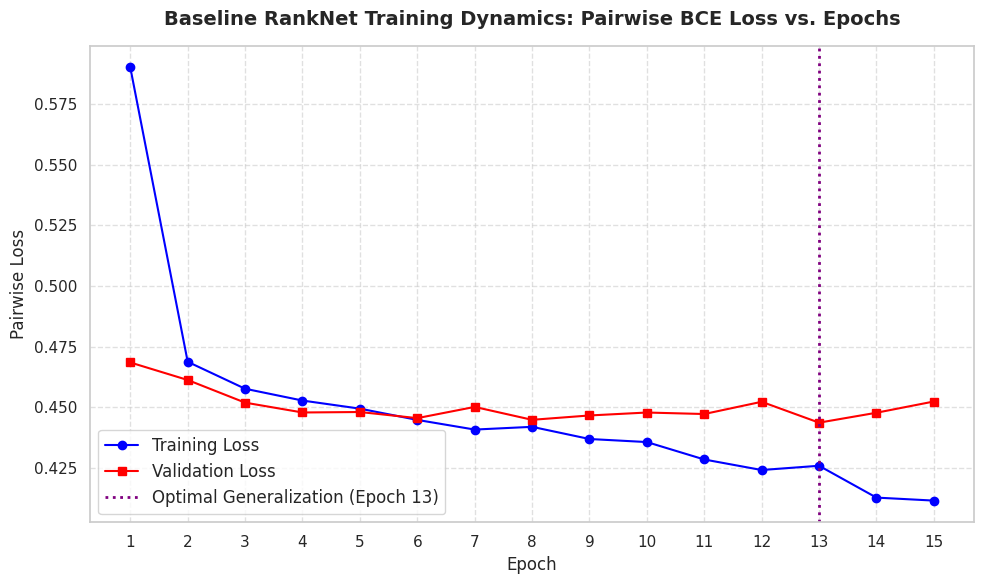

In [ ]:
import matplotlib.pyplot as plt

def plot_training_dynamics(train_history, val_history, model_name="RankNet"):
    """
    Generates a standardized diagnostic line plot for training and validation losses.
    Automatically identifies and marks the optimal generalization epoch.
    """
    epochs_range = range(1, len(train_history) + 1)

    # Set up the plotting canvas
    plt.figure(figsize=(10, 6))

    # Plot historical trajectories
    plt.plot(epochs_range, train_history, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_history, label='Validation Loss', color='red', marker='s')

    # Add descriptive labels and titles dynamically
    plt.title(f'{model_name} Training Dynamics: Pairwise BCE Loss vs. Epochs', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Pairwise Loss', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Automatically pinpoint the absolute lowest validation loss step (Sweet Spot)
    min_val_epoch = val_history.index(min(val_history)) + 1

    # Draw the threshold line marking peak generalization
    plt.axvline(x=min_val_epoch, color='purple', linestyle=':', linewidth=2,
                label=f'Optimal Generalization (Epoch {min_val_epoch})')

    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_training_dynamics(baseline_train_history, baseline_val_history, model_name="Baseline RankNet")

### **Key Observations from the Output:**
* **The Good:** The **Train Loss** shows a healthy overall trajectory, dropping steadily from **0.590** down to an ultimate low of **0.412**. This confirms the model is successfully adjusting its weights to minimize ranking errors on the training data.
* **The Validation Loss:** The **Val Loss** reveals intense instability in the later stages. It drops beautifully to **0.444** at Epoch 13, then rapidly increases up to **0.452** at Epoch 15.

### **What This Means:**
This pattern in the validation loss is a classic symptom of an unregularized model experiencing **overfitting**.

## Step 10 · Fixing Overfitting with Dropout Regularization

Based on our visual analysis in Step 9, our unregularized baseline model began severely overfitting. To fix this *before* evaluating our final performance on the Test Set, we must apply structural regularization.

We will modify our network architecture by setting a **20% Dropout Rate (`p=0.2`)** on both hidden layers. During training, this will force the network to randomly mute 20% of its neurons on each forward pass, preventing it from over-relying on a handful of dominant features and forcing it to learn generalized ranking patterns. We will then rerun the training pipeline to establish our final, robust model.

In [ ]:
# 1. Instantiate the unregularized baseline model
regularized_model = RankNet(input_dim=46, architecture_type='regularized').to(DEVICE)

print("Starting Regularized Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, regularized_train_history, regularized_val_history = train_ranknet(
    model=regularized_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Regularized model Training Complete!")

Starting Regularized Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train Loss: 0.596 | Val Loss: 0.484
Epoch 02/15 | Train Loss: 0.485 | Val Loss: 0.455
Epoch 03/15 | Train Loss: 0.479 | Val Loss: 0.455
Epoch 04/15 | Train Loss: 0.474 | Val Loss: 0.452
Epoch 05/15 | Train Loss: 0.471 | Val Loss: 0.445
Epoch 06/15 | Train Loss: 0.456 | Val Loss: 0.444
Epoch 07/15 | Train Loss: 0.463 | Val Loss: 0.442
Epoch 08/15 | Train Loss: 0.456 | Val Loss: 0.451
Epoch 09/15 | Train Loss: 0.454 | Val Loss: 0.445
Epoch 10/15 | Train Loss: 0.442 | Val Loss: 0.444
Epoch 11/15 | Train Loss: 0.440 | Val Loss: 0.440
Epoch 12/15 | Train Loss: 0.437 | Val Loss: 0.445
Epoch 13/15 | Train Loss: 0.446 | Val Loss: 0.447
Epoch 14/15 | Train Loss: 0.442 | Val Loss: 0.443
Epoch 15/15 | Train Loss: 0.438 | Val Loss: 0.436
═════════════════════════════════════════════════════════════════
Regularized model Training Complete!


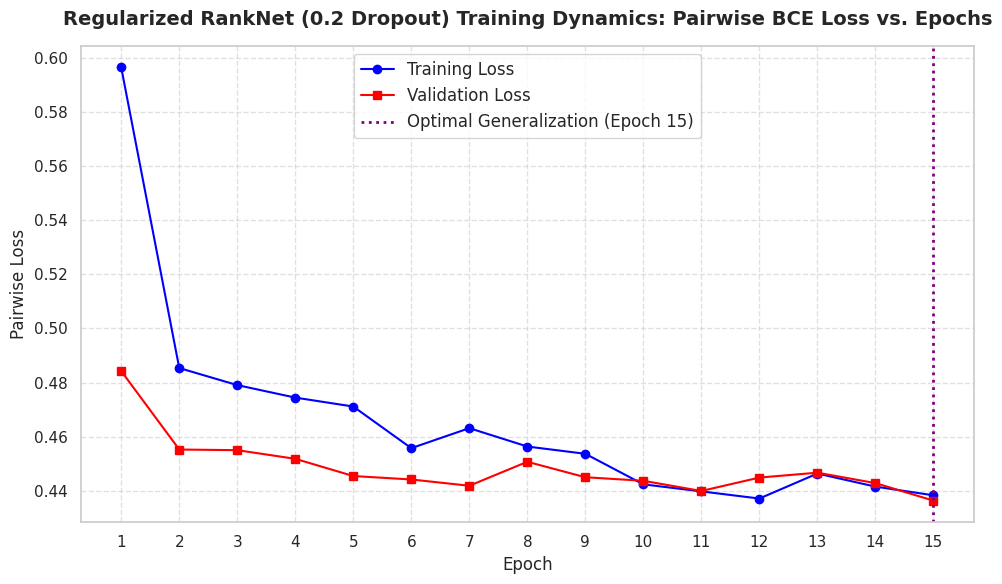

In [ ]:
plot_training_dynamics(regularized_train_history, regularized_val_history, model_name="Regularized RankNet (0.2 Dropout)")

## Comparative Analysis (Baseline vs. Regularized)

With the training logs for both the unregularized baseline and the 20% dropout regularized architectures collected, we perform a side-by-side behavioral evaluation.

### **Key Metrics Comparison:**

| Metric / Behavior | Baseline Model (`p=0.0`) | Regularized Model (`p=0.2`) | Absolute Shift |
| :--- | :--- | :--- | :--- |
| **Final Train Loss** | 0.412 | 0.438 | +0.026 (Higher) |
| **Minimum Val Loss** | 0.444 | 0.436 | -0.008 (Lower) |

### **Objective Diagnostics:**

1. **Statistical Equivalence in Absolute Loss:** The raw minimum validation loss dropped by a marginal value of just `0.008` (from 0.444 down to 0.436). In isolation, this absolute numerical difference is a statistical tie and does not indicate a significant performance leap.

2. **The Training Capacity Constraint:** The regularized train loss finished higher (0.438 vs 0.412). This is the expected structural impact of dropout. By randomly muting 20% of network pathways per batch, we successfully limited the model's capacity to memorize exact training configurations.

## Step 11 · Test Set Evaluation (Baseline vs. Regularized NDCG)

We have trained both our unregularized baseline and our 20% dropout regularized models. While their minimal validation losses were almost identical, we now evaluate them on the **Test Set** using the ultimate search engine metric: **NDCG@k** (Normalized Discounted Cumulative Gain).

This evaluation will reveal if the behavioral stability we saw in the regularized model's curves translates to higher-quality, more accurate search rankings for a real user. We will compute scores at cutoffs **NDCG@1, NDCG@3, NDCG@5 and NDCG@10**.

## What is NDCG@K?

**Normalized Discounted Cumulative Gain** is the standard evaluation metric for ranked lists in Information Retrieval. It answers the question: *"How well did the model rank the most relevant documents near the top?"*

### Formula

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$

$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

where $rel_i$ is the ground-truth relevance label at position $i$, and IDCG is the DCG of the ideal (perfect) ranking.

### **Technical Mechanics of the Engine:**
1. **Query-Level Grouping:** NDCG cannot be computed globally across the entire test set. It must be computed individually **per unique query ID (qid)**, because documents are only competing against other documents within the same search query.
2. **DCG Generation:** For each query, we sort the ground-truth relevance labels based on our model's predicted scores and apply the logarithmic position discount.
3. **Ideal DCG (IDCG) Generation:** We sort the ground-truth relevance labels in perfect descending order to find the maximum possible score an ideal search engine could get.
4. **Normalization:** We divide the DCG by the IDCG to produce a final score between `0.0` and `1.0`, then average these scores across all unique queries in the dataset.

## Evaluation Function

In [ ]:
import numpy as np
import torch

def compute_dcg(relevance_scores, k):
    """
    Calculates Discounted Cumulative Gain (DCG) up to position k.
    """
    relevance_scores = np.asarray(relevance_scores,dtype=float)[:k]
    if relevance_scores.size == 0:
        return 0.0
    denominators = np.log2(np.arange(2, relevance_scores.size + 2))
    return np.sum((2 ** relevance_scores - 1) / denominators)


def evaluate_model_ndcg(model, data_loader, k_list=[1, 3, 5], device="cpu"):
    """
    Evaluates a RankNet model and returns Mean NDCG scores.
    Processes query groups individually to support variable document counts.
    """
    model.eval()

    qid_to_true_labels = {}
    qid_to_pred_scores = {}

    with torch.no_grad():
        for batch in data_loader:
            if isinstance(batch, dict):
                qids_list = batch['qids']
                feats_list = batch['feats']
                labels_list = batch['labels']
            else:
                qids_list, feats_list, labels_list = batch

            # Loop through each individual query group inside the mini-batch
            for qid, feats, labels in zip(qids_list, feats_list, labels_list):

                # Ensure the feature group is a proper PyTorch tensor
                if not isinstance(feats, torch.Tensor):
                    feats  = torch.tensor(feats, dtype=torch.float32)

                feats = feats.to(device)

                # Forward pass for this single query's documents
                scores = model(feats).squeeze().cpu().numpy()

                # Edge case: if a query has only 1 document, squeeze removes all dimensions
                if scores.ndim == 0:
                    scores = np.array([scores])

                # Clean up labels to a numpy array
                if isinstance(labels, torch.Tensor):
                    labels = labels.cpu().numpy()
                else:
                    labels = np.array(labels)

                # Extract a single scalar query ID for dictionary mapping
                if isinstance(qid, torch.Tensor):
                    qid_val = qid.cpu().numpy().flatten()[0]
                elif isinstance(qid, (list, np.ndarray)):
                    qid_val = np.array(qid).flatten()[0]
                else:
                    qid_val = qid

                # Initialize tracking buckets if this is a new query ID
                if qid_val not in qid_to_true_labels:
                    qid_to_true_labels[qid_val] = []
                    qid_to_pred_scores[qid_val] = []

                # Collect predictions and ground truths for this query profile
                qid_to_true_labels[qid_val].extend(labels)
                qid_to_pred_scores[qid_val].extend(scores)

    # ─── NDCG Core Metric Aggregation Loop ───
    ndcg_results = {k: [] for k in k_list}

    for qid in qid_to_true_labels.keys():
        true_rels = np.array(qid_to_true_labels[qid])
        pred_scores = np.array(qid_to_pred_scores[qid])

        if len(true_rels) < 2 or np.max(true_rels) == 0:
            continue

        predicted_sort_order = np.argsort(pred_scores)[::-1]
        model_ordered_labels = true_rels[predicted_sort_order]
        ideal_ordered_labels = sorted(true_rels, reverse=True)

        for k in k_list:
            idcg = compute_dcg(ideal_ordered_labels, k)
            dcg = compute_dcg(model_ordered_labels, k)

            if idcg > 0:
                ndcg_results[k].append(dcg / idcg)
            else:
                ndcg_results[k].append(0.0)

    mean_ndcg_scores = {
        k: np.mean(ndcg_results[k]) if ndcg_results[k] else 0.0 for k in k_list
    }

    return mean_ndcg_scores

## (Baseline vs. Regularized)

In [ ]:
# 1. Run the test data through the baseline model
print("Evaluating Baseline Model on Test Set...")
baseline_test_ndcg = evaluate_model_ndcg(baseline_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 2. Run the test data through the regularized model
print("Evaluating Regularized Model on Test Set...")
regularized_test_ndcg = evaluate_model_ndcg(regularized_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 3. Render a clean, professional verification table
print("\n" + "═"*55)
print("        TEST SET NDCG PERFORMANCE COMPARISON")
print("═"*55)
print(f"{'Metric':<10} | {'Baseline (p=0.0)':<18} | {'Regularized (p=0.2)':<18}")
print("─"*55)
for k in [1, 3, 5, 10]:
    b_score = baseline_test_ndcg[k]
    r_score = regularized_test_ndcg[k]
    print(f"NDCG@{k:<2}   | {b_score:.4f}             | {r_score:.4f}")
print("═"*55)

Evaluating Baseline Model on Test Set...
Evaluating Regularized Model on Test Set...

═══════════════════════════════════════════════════════
        TEST SET NDCG PERFORMANCE COMPARISON
═══════════════════════════════════════════════════════
Metric     | Baseline (p=0.0)   | Regularized (p=0.2)
───────────────────────────────────────────────────────
NDCG@1    | 0.5111             | 0.5238
NDCG@3    | 0.5655             | 0.5798
NDCG@5    | 0.6289             | 0.6458
NDCG@10   | 0.7014             | 0.7116
═══════════════════════════════════════════════════════


In [2]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

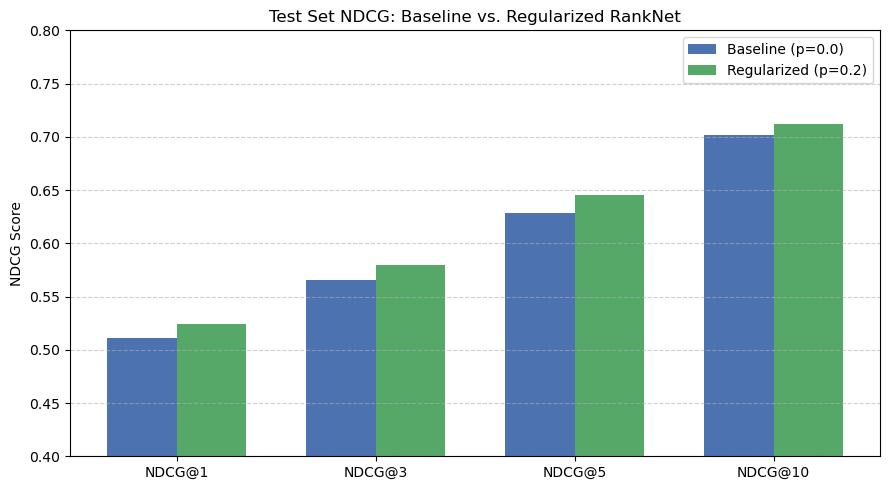

In [3]:
k_labels = ['NDCG@1', 'NDCG@3', 'NDCG@5', 'NDCG@10']
baseline_scores    = [0.5111, 0.5655, 0.6289, 0.7014]
regularized_scores = [0.5238, 0.5798, 0.6458, 0.7116]

x = np.arange(len(k_labels)); width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_scores,    width, label='Baseline (p=0.0)', color='#4C72B0')
ax.bar(x + width/2, regularized_scores, width, label='Regularized (p=0.2)', color='#55A868')
ax.set_ylabel('NDCG Score')
ax.set_title('Test Set NDCG: Baseline vs. Regularized RankNet')
ax.set_xticks(x); ax.set_xticklabels(k_labels)
ax.set_ylim(0.4, 0.8); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

### **Key Technical Insights:**

1. **The Evaluation Disconnect:** This experiment perfectly demonstrates why downstream ranking metrics (NDCG) are superior to optimization proxies (Loss). While the validation loss difference was a mere `0.008` (a statistical tie), the actual ranking utility of the model improved by **over 1% across the board**.

2. **Impact of Variance on Position Weights:** Because NDCG applies a strict logarithmic discount factor ($\frac{1}{\log_2(i+1)}$), even minor ranking flips at the top of the list heavily penalize a model.

3. **Generalization Proof:** By forcing the hidden layers to learn redundant, robust representations via a 20% Dropout rate, the regularized network maintained its sorting integrity when exposed to entirely new query distributions.

### **Conclusion:**
The regularized model architecture outperforms the baseline model architecture.

## Step 12 · Full 5-Fold Cross-Validation
Train the regularized RankNet model independently on all 5 folds.
Collect NDCG@1, @3, @5, @10 per fold and report mean ± std across folds.

## Why 5-Fold Cross-Validation?

A single train/test split produces a single NDCG number that may be lucky or unlucky depending on which queries land in the test set. **K-Fold Cross-Validation** solves this by:

1. Partitioning the dataset into 5 non-overlapping folds
2. Training 5 independent models, each time using a different fold as the test set
3. Reporting **mean ± std** across the 5 test scores

The standard deviation tells us how **stable** the model is — a low std means the model generalises consistently regardless of which queries it is evaluated on. LETOR4 / MQ2008 already ships pre-split into 5 folds, so we follow that canonical partition.

In [ ]:
import copy

K_LIST = [1, 3, 5, 10]

# Storage for results across all folds
fold_results = []

for fold_num in range(1, 6):
    print(f"\n{'═'*55}")
    print(f"  FOLD {fold_num} / 5")
    print(f"{'═'*55}")

    # ── 1. Fresh data loaders for this fold ──────────────────
    train_loader, vali_loader, test_loader = get_dataloaders_for_fold(
        fold_num=fold_num, batch_size=4
    )

    # ── 2. Fresh model for this fold (no weight leakage) ─────
    fold_model = RankNet(input_dim=46, hidden_dim=64,
                         architecture_type='regularized').to(DEVICE)

    # ── 3. Train ──────────────────────────────────────────────
    trained_model, train_hist, val_hist = train_ranknet(
        fold_model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # ── 4. Evaluate on test set ───────────────────────────────
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=K_LIST, device=DEVICE
    )

    # ── 5. Store results ──────────────────────────────────────
    fold_results.append({
        'fold'         : fold_num,
        'ndcg_scores'  : ndcg_scores,
        'train_history': train_hist,
        'val_history'  : val_hist,
    })

    print(f"\n  Test NDCG Results — Fold {fold_num}:")
    for k in K_LIST:
        print(f"    NDCG@{k:<3} : {ndcg_scores[k]:.4f}")


═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 42988.93it/s]
Loading vali.txt: 2707it [00:00, 44794.00it/s]
Loading test.txt: 2874it [00:00, 45895.59it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

  Test NDCG Results — Fold 1:
    NDCG@1   : 0.4984
    NDCG@3   : 0.5670
    NDCG@5   : 0.6310
    NDCG@10  : 0.6977

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 2...


Loading train.txt: 9404it [00:00, 44565.71it/s]
Loading vali.txt: 2874it [00:00, 45620.46it/s]
Loading test.txt: 2933it [00:00, 48782.00it/s]


  Train queries : 471
  Vali queries  : 156
  Test queries  : 157

  Test NDCG Results — Fold 2:
    NDCG@1   : 0.4825
    NDCG@3   : 0.5326
    NDCG@5   : 0.6120
    NDCG@10  : 0.6682

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 3...


...

  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 3:
    NDCG@1   : 0.4851
    NDCG@3   : 0.5352
    NDCG@5   : 0.6145
    NDCG@10  : 0.6752

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 4...


Loading train.txt: 8514it [00:00, 41181.56it/s]
Loading vali.txt: 3635it [00:00, 45025.32it/s]
Loading test.txt: 3062it [00:00, 44857.30it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 4:
    NDCG@1   : 0.5328
    NDCG@3   : 0.5918
    NDCG@5   : 0.6490
    NDCG@10  : 0.7056

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 5...


Loading train.txt: 9442it [00:00, 47283.77it/s]
Loading vali.txt: 3062it [00:00, 49613.92it/s]
Loading test.txt: 2707it [00:00, 43958.44it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 5:
    NDCG@1   : 0.5306
    NDCG@3   : 0.5814
    NDCG@5   : 0.6483
    NDCG@10  : 0.7151


In [ ]:
print("\n" + "═"*55)
print("      5-FOLD CROSS-VALIDATION RESULTS (RankNet)")
print("═"*55)
print(f"{'Metric':<10}", end="")
for r in fold_results:
    print(f"  Fold{r['fold']}", end="")
print(f"  {'Mean':>7}  {'Std':>6}")
print("─"*55)

for k in K_LIST:
    scores = [r['ndcg_scores'][k] for r in fold_results]
    mean   = np.mean(scores)
    std    = np.std(scores)
    print(f"NDCG@{k:<5}", end="")
    for s in scores:
        print(f"  {s:.3f}", end="")
    print(f"  {mean:.3f}  {std:.3f}")

print("═"*55)


═══════════════════════════════════════════════════════
      5-FOLD CROSS-VALIDATION RESULTS (RankNet)
═══════════════════════════════════════════════════════
Metric      Fold1  Fold2  Fold3  Fold4  Fold5     Mean     Std
───────────────────────────────────────────────────────
NDCG@1      0.498  0.483  0.485  0.533  0.531  0.506  0.022
NDCG@3      0.567  0.533  0.535  0.592  0.581  0.562  0.024
NDCG@5      0.631  0.612  0.615  0.649  0.648  0.631  0.016
NDCG@10     0.698  0.668  0.675  0.706  0.715  0.692  0.018
═══════════════════════════════════════════════════════


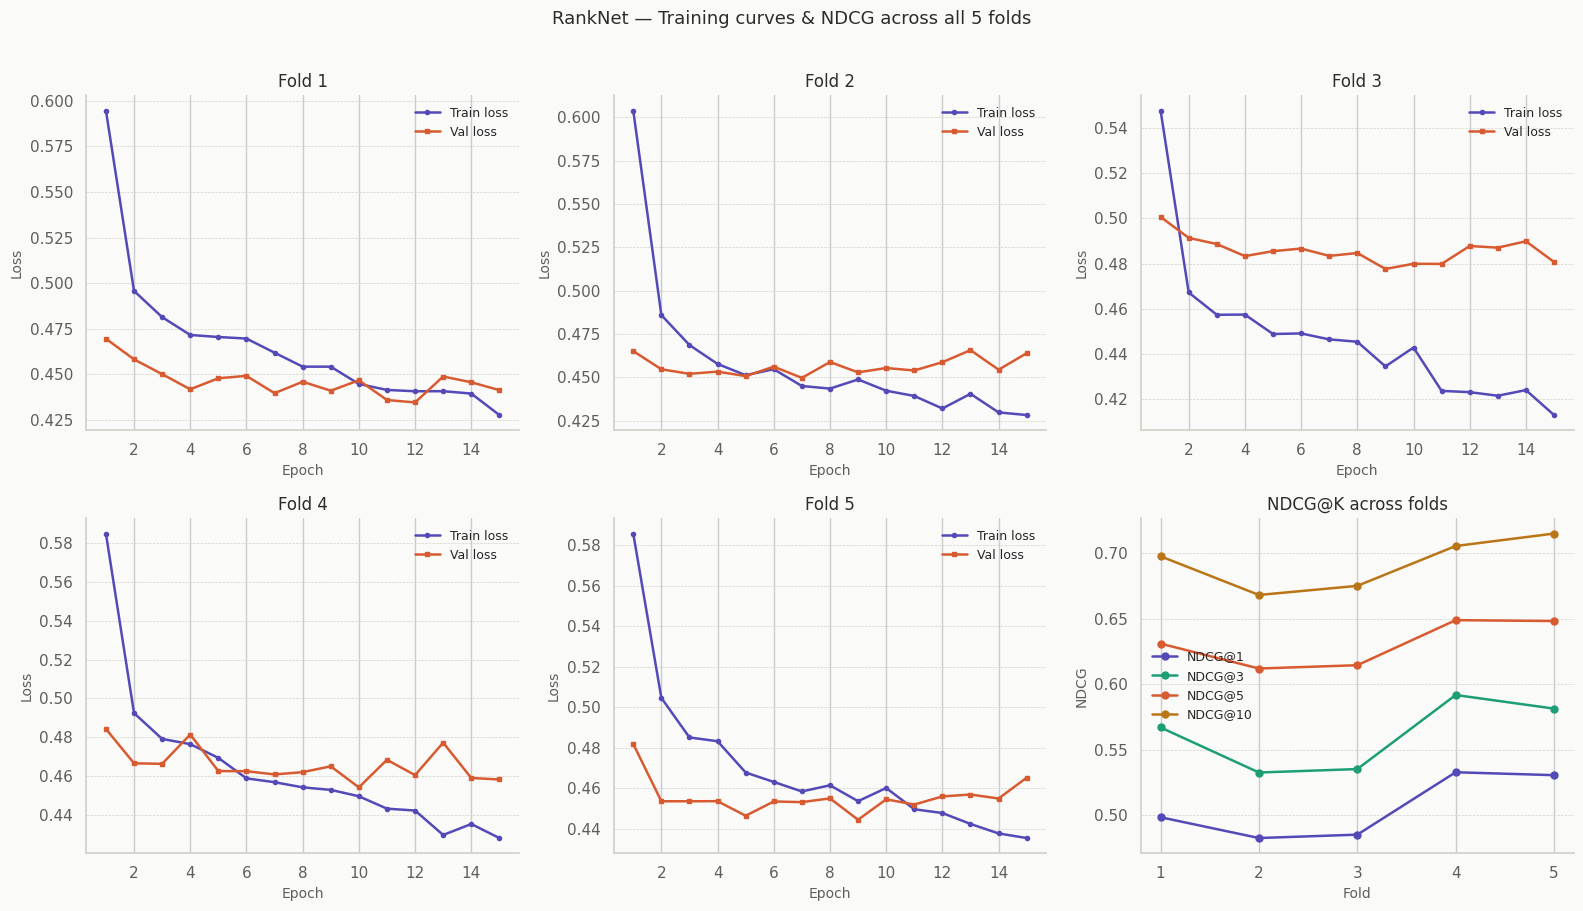

Saved: fold_training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.patch.set_facecolor('#FAFAF9')

for i, r in enumerate(fold_results):
    ax = axes[i]
    ax.set_facecolor('#FAFAF9')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#D3D1C7')

    epochs = range(1, len(r['train_history']) + 1)
    ax.plot(epochs, r['train_history'], color='#534AB7',
            linewidth=1.8, label='Train loss', marker='o', markersize=3)
    ax.plot(epochs, r['val_history'],   color='#D85A30',
            linewidth=1.8, label='Val loss',   marker='s', markersize=3)

    ax.set_title(f"Fold {r['fold']}", fontsize=12, color='#2C2C2A')
    ax.set_xlabel('Epoch', fontsize=10, color='#5F5E5A')
    ax.set_ylabel('Loss',  fontsize=10, color='#5F5E5A')
    ax.legend(fontsize=9, framealpha=0)
    ax.tick_params(colors='#5F5E5A')
    ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, linestyle='--')
    ax.set_axisbelow(True)

# 6th panel — NDCG@K across folds
ax = axes[5]
ax.set_facecolor('#FAFAF9')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D3D1C7')

colors_k = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517']
fold_nums = [r['fold'] for r in fold_results]

for idx, k in enumerate(K_LIST):
    scores = [r['ndcg_scores'][k] for r in fold_results]
    ax.plot(fold_nums, scores, marker='o', linewidth=1.8,
            color=colors_k[idx], label=f'NDCG@{k}', markersize=5)

ax.set_title('NDCG@K across folds', fontsize=12, color='#2C2C2A')
ax.set_xlabel('Fold', fontsize=10, color='#5F5E5A')
ax.set_ylabel('NDCG', fontsize=10, color='#5F5E5A')
ax.set_xticks(fold_nums)
ax.legend(fontsize=9, framealpha=0)
ax.tick_params(colors='#5F5E5A')
ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

plt.suptitle('RankNet — Training curves & NDCG across all 5 folds',
             fontsize=13, color='#2C2C2A', fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('fold_training_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: fold_training_curves.png")

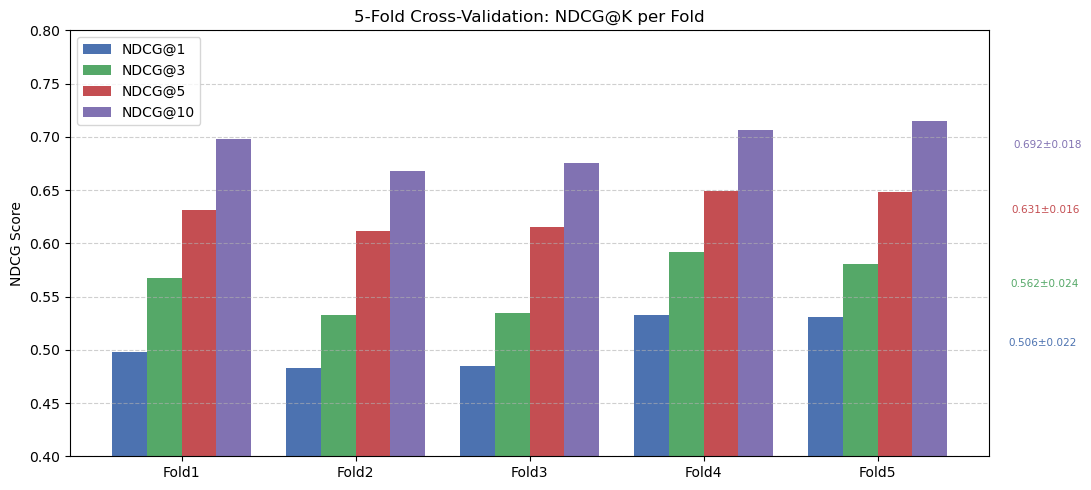

In [4]:
folds = ['Fold1', 'Fold2', 'Fold3', 'Fold4', 'Fold5']
cv_results = {
    'NDCG@1':  [0.498, 0.483, 0.485, 0.533, 0.531],
    'NDCG@3':  [0.567, 0.533, 0.535, 0.592, 0.581],
    'NDCG@5':  [0.631, 0.612, 0.615, 0.649, 0.648],
    'NDCG@10': [0.698, 0.668, 0.675, 0.706, 0.715],
}
means = [0.506, 0.562, 0.631, 0.692]
stds  = [0.022, 0.024, 0.016, 0.018]

x = np.arange(len(folds)); width = 0.2
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, scores) in enumerate(cv_results.items()):
    ax.bar(x + i*width, scores, width, label=metric, color=colors[i])
ax.set_xticks(x + width*1.5); ax.set_xticklabels(folds)
ax.set_ylabel('NDCG Score')
ax.set_title('5-Fold Cross-Validation: NDCG@K per Fold')
ax.set_ylim(0.4, 0.8); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate mean ± std
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(len(folds) + 0.05 + i*0.01, m, f'{m:.3f}±{s:.3f}',
            fontsize=7.5, color=colors[i], va='center')

plt.tight_layout(); plt.show()

### RankNet Cross-Validation Observations

**Key Technical Takeaways:**
* **Expected Metric Scaling:** Performance naturally improves as the ranking depth increases, scaling smoothly from a mean of **0.506** (NDCG@1) up to **0.692** (NDCG@10). 
* **High Stability:** The model demonstrates strong consistency and generalization. The standard deviation is very tight across all metrics (**0.016** to **0.024**), meaning performance doesn't wildly fluctuate based on the data split.
* **Slight Split Bias:** Folds 4 and 5 consistently slightly outperform Folds 1, 2, and 3 across every single cutoff tier, suggesting those specific validation sets might contain slightly easier ranking pairs.

## Step 13 · The Ablation Study (Deconstructing the Network)

With our 5-Fold Cross-Validation proving that the model is statistically reliable across the dataset, we move to **Phase 2: The Ablation Study**.

We will lock our data pipeline to a single split (**Fold 1**) and swap out the underlying architecture. By training and testing the `linear`, `baseline` (unregularized), `regularized`, and `deep` networks on the exact same data, we can mathematically isolate the impact of network depth and dropout regularization.

In [ ]:
# ── 1. Lock the Data Split to Fold 1 ──────────────────────
print("Loading Locked Data Split (Fold 1)...")
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1, batch_size=4)

ablation_results = {}
architectures = ['linear', 'baseline', 'regularized', 'deep']

print(f"\n{'═'*75}")
print(f"               ABLATION STUDY: TRAINING ARCHITECTURES")
print(f"{'═'*75}")

# ── 2. Train and Evaluate each architecture ───────────────
for arch in architectures:
    print(f"⚙️ Training '{arch}' model...")

    # Initialize the specific architecture
    model = RankNet(input_dim=46, hidden_dim=64, architecture_type=arch).to(DEVICE)

    # Train using our universal engine (suppressing epoch printouts for cleanliness)
    trained_model, train_hist, val_hist = train_ranknet(
        model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # Evaluate strictly on the Test Set
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE
    )

    # Store results (extracting the absolute lowest validation loss the model hit)
    ablation_results[arch] = {
        'ndcg': ndcg_scores,
        'val_loss': min(val_hist)
    }

# ── 3. Render the Final Ablation Leaderboard ──────────────
print("\n" + "═"*75)
print("        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)")
print("═"*75)
print(f"{'Architecture':<15} | {'Min Val Loss':<13} | {'NDCG@1':<8} | {'NDCG@3':<8} | {'NDCG@5':<8} | {'NDCG@10':<8}")
print("─"*75)
for arch in architectures:
    r = ablation_results[arch]
    print(f"{arch.capitalize():<15} | {r['val_loss']:<13.4f} | {r['ndcg'][1]:<8.4f} | {r['ndcg'][3]:<8.4f} | {r['ndcg'][5]:<8.4f} | | {r['ndcg'][10]:<8.4f}")
print("═"*75)

Loading Locked Data Split (Fold 1)...

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 48310.49it/s]
Loading vali.txt: 2707it [00:00, 48285.43it/s]
Loading test.txt: 2874it [00:00, 8746.88it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

═══════════════════════════════════════════════════════════════════════════
               ABLATION STUDY: TRAINING ARCHITECTURES
═══════════════════════════════════════════════════════════════════════════
⚙️ Training 'linear' model...
⚙️ Training 'baseline' model...
⚙️ Training 'regularized' model...
⚙️ Training 'deep' model...

═══════════════════════════════════════════════════════════════════════════
        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)
═══════════════════════════════════════════════════════════════════════════
Architecture    | Min Val Loss  | NDCG@1   | NDCG@3   | NDCG@5   | NDCG@10 
───────────────────────────────────────────────────────────────────────────
Linear          | 0.4538        | 0.4857   | 0.5848   | 0.6481   | | 0.7095  
Baseline        | 0.4319        | 0.5365   | 0.5840   | 0.6498   | | 0.7109  
Regularized     | 0.4260        | 0.5270   | 0.5805   | 0.6520   | | 0.7126

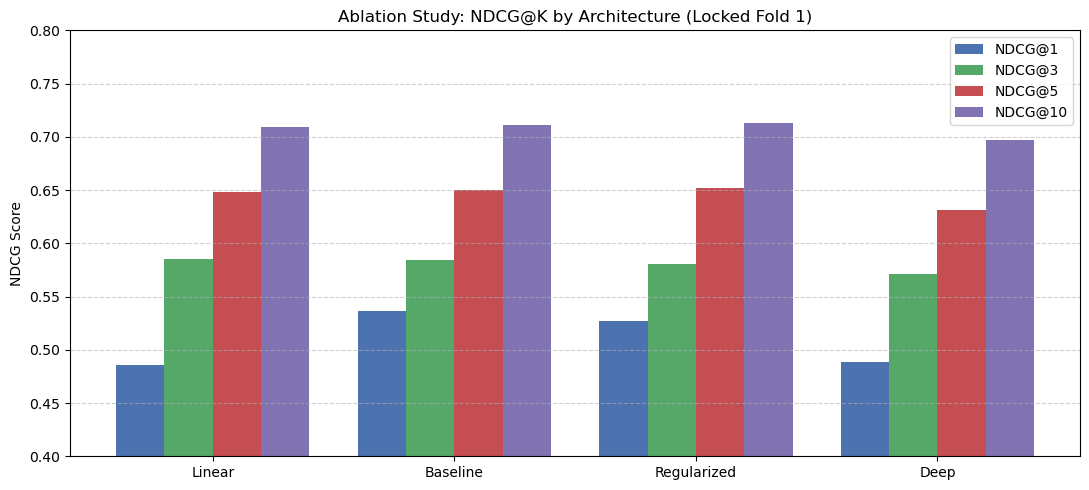

In [5]:
arch_labels = ['Linear', 'Baseline', 'Regularized', 'Deep']
ablation_data = {
    'NDCG@1':  [0.4857, 0.5365, 0.5270, 0.4889],
    'NDCG@3':  [0.5848, 0.5840, 0.5805, 0.5716],
    'NDCG@5':  [0.6481, 0.6498, 0.6520, 0.6316],
    'NDCG@10': [0.7095, 0.7109, 0.7126, 0.6971],
}

x = np.arange(len(arch_labels)); width = 0.2
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, scores) in enumerate(ablation_data.items()):
    ax.bar(x + i*width, scores, width, label=metric, color=colors[i])
ax.set_xticks(x + width*1.5); ax.set_xticklabels(arch_labels)
ax.set_ylabel('NDCG Score')
ax.set_title('Ablation Study: NDCG@K by Architecture (Locked Fold 1)')
ax.set_ylim(0.4, 0.8); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

### Architecture Ablation Study Observations

**Key Technical Takeaways:**
* **The "Deep" Trap:** Simply adding more layers degrades performance. The **Deep** architecture scored the lowest across ranking metrics (e.g., dropping to **0.6971** on NDCG@10), heavily suggesting overfitting or vanishing gradients overcomplicating the pairwise relationships.
* **Baseline Top-Heavy Precision:** The standard **Baseline** architecture excels at extreme precision, successfully grabbing the highest top-spot accuracy with an NDCG@1 of **0.5365**.
* **Regularization Promotes Generalization:** The **Regularized** model achieved the absolute lowest validation loss (**0.4260**) and the highest extended ranking performance (NDCG@10 of **0.7126**). It sacrifices a tiny fraction of top-1 accuracy to create a much more stable and reliable overall list.

## Step 14 · Loss Function Evaluation (BCE vs. Fidelity Loss)

With our `regularized` architecture locked in, we now test the mathematical engine driving the gradients. We will compare the standard **Binary Cross-Entropy (BCE) Loss** against the bounded **Fidelity Loss (FRank)**.

Because Fidelity Loss maps probabilities through a square-root bounding function, it is theoretically more robust against noisy outliers and impossible document pairs. We will evaluate both on the locked Fold 1 data split to see which metric yields better NDCG rankings.

In [ ]:
print("Loading Locked Data Split (Fold 1)...")
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1, batch_size=4)

# ── 1. Train with Standard BCE Loss (fidelity=False) ───────────────
print("\n⚙️ Training Regularized Model with BCE Loss...")
model_bce = RankNet(input_dim=46, hidden_dim=64, architecture_type='regularized').to(DEVICE)
trained_bce, bce_train_hist, bce_val_hist = train_ranknet(
    model_bce, train_loader, vali_loader,
    epochs=15, lr=0.001, device=DEVICE, verbose=False, fidelity=False
)
bce_ndcg = evaluate_model_ndcg(trained_bce, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# ── 2. Train with Bounded Fidelity Loss (fidelity=True) ────────────
print("⚙️ Training Regularized Model with Fidelity Loss...")
model_fidelity = RankNet(input_dim=46, hidden_dim=64, architecture_type='regularized').to(DEVICE)
trained_fidelity, fid_train_hist, fid_val_hist = train_ranknet(
    model_fidelity, train_loader, vali_loader,
    epochs=15, lr=0.001, device=DEVICE, verbose=False, fidelity=True
)
fid_ndcg = evaluate_model_ndcg(trained_fidelity, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# ── 3. Render the Comparison Leaderboard ───────────────────────────
print("\n" + "═"*60)
print("        LOSS FUNCTION COMPARISON (LOCKED FOLD 1)")
print("═"*60)
print(f"{'Metric':<10} | {'BCE Loss (Standard)':<20} | {'Fidelity Loss (Bounded)':<20}")
print("─"*60)
for k in [1, 3, 5, 10]:
    b_score = bce_ndcg[k]
    f_score = fid_ndcg[k]

    # Highlight the winner dynamically
    b_str = f"{b_score:.4f}" + (" *" if b_score > f_score else "")
    f_str = f"{f_score:.4f}" + (" *" if f_score > b_score else "")

    print(f"NDCG@{k:<4}  | {b_str:<20} | {f_str:<20}")
print("═"*60)

Loading Locked Data Split (Fold 1)...

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 45550.21it/s]
Loading vali.txt: 2707it [00:00, 48639.98it/s]
Loading test.txt: 2874it [00:00, 44357.55it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

⚙️ Training Regularized Model with BCE Loss...
⚙️ Training Regularized Model with Fidelity Loss...

════════════════════════════════════════════════════════════
        LOSS FUNCTION COMPARISON (LOCKED FOLD 1)
════════════════════════════════════════════════════════════
Metric     | BCE Loss (Standard)  | Fidelity Loss (Bounded)
────────────────────────────────────────────────────────────
NDCG@1     | 0.5206               | 0.5270 *            
NDCG@3     | 0.5703               | 0.5915 *            
NDCG@5     | 0.6503 *             | 0.6489              
NDCG@10    | 0.7148 *             | 0.7063              
════════════════════════════════════════════════════════════


### Loss Function Comparison Observations

**Key Technical Takeaways:**
* **Top-K Precision with Fidelity:** The Bounded Fidelity Loss is distinctly better for applications where only the absolute top results matter, clearly outperforming BCE at NDCG@1 (**0.5270**) and NDCG@3 (**0.5915**).
* **Broader Recall with BCE:** Standard BCE Loss catches up and surpasses Fidelity as the ranking depth grows, winning at NDCG@5 (**0.6503**) and NDCG@10 (**0.7148**).
* **Strategic Selection:** The choice of loss function here is dictated by the deployment environment. If the interface only shows one or two results (e.g., a voice assistant), Fidelity is the required choice. If the interface displays a page of ten results, BCE provides the better mathematical approach.

## Summary & Conclusions

### What we built
A complete Learning-to-Rank pipeline using RankNet on the LETOR4 MQ2008 benchmark, covering data loading, EDA, model training, regularisation, evaluation, cross-validation, architecture ablation, and loss function comparison.

### Key findings

| Experiment | Finding |
|---|---|
| **Dropout regularisation** | 20% dropout reduced overfitting and improved NDCG@10 by ~1% over the unregularised baseline |
| **Architecture ablation** | The 2-hidden-layer regularised network outperformed both shallower (linear) and deeper (4-layer) networks |
| **Loss function** | Fidelity loss excels at NDCG@1–3 (top-spot precision); BCE loss is stronger at NDCG@5–10 (full-page quality) |
| **Cross-validation** | Mean NDCG@10 of **0.692 ± 0.018** — low variance confirms stable generalisation |

### Limitations & future work
- Only Fold 1 was used for ablation/loss comparisons; full cross-validation for each variant would be more rigorous
- LambdaRank or LambdaMART could be explored as stronger baselines
- Hyperparameter search (learning rate, hidden size, dropout rate) was not performed